In [1]:
import pandas as pd

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
%matplotlib inline

In [4]:
df=pd.read_csv('height-weight.csv')
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'Height')

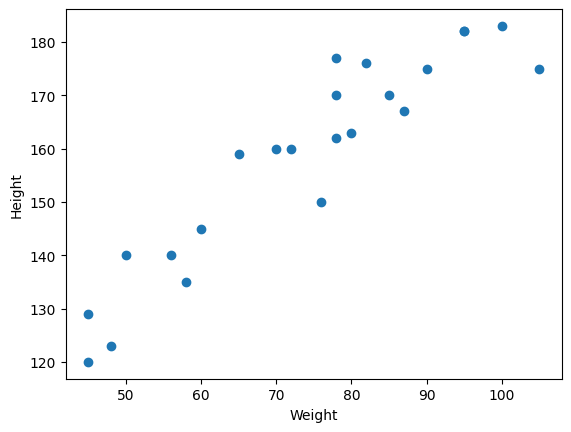

In [5]:
### scatter  plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [6]:
### finding the correlation between weight and height
df.corr()

,Weight,Height
Weight,1.000000,0.931142
Height,0.931142,1.000000


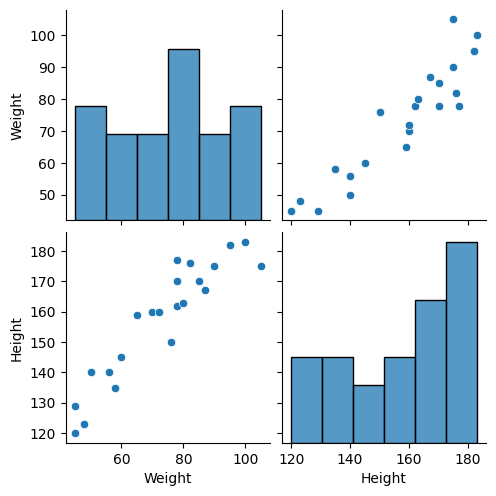

In [7]:
import seaborn as sns
sns.pairplot(df)

In [8]:
### Independent and dependent variable
X=df[['Weight']] ### independent features should be data frame or 2D array
np.array(X).shape
X.head()
y=df['Height'] ### dependent features should be series or 1D array

In [9]:
X_series=df['Weight']
np.array(X_series).shape

(23,)

In [10]:
### Train test split

from sklearn.model_selection import train_test_split


In [16]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42 )

In [17]:
X_train.shape

(17, 1)

In [18]:
### Standardization

from sklearn.preprocessing import StandardScaler

In [20]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)

In [21]:
## In the X_train we use tranform not fit transform because we want to use the same mean and standard deviation that we calculated from the training data to scale the test data. If we were to use fit_transform on the test data, it would calculate a new mean and standard deviation based on the test data, which could lead to data leakage and inaccurate model performance evaluation. By using transform, we ensure that the test data is scaled in the same way as the training data, allowing for a fair assessment of the model's performance on unseen data.

In [22]:
X_test=scaler.transform(X_test)

In [23]:
X_test

array([[ 0.33497168],
       [ 0.33497168],
       [-1.6641678 ],
       [ 1.36483141],
       [-0.45256812],
       [ 1.97063125]])

In [24]:
### Apply Linear Regression
from sklearn.linear_model import LinearRegression

In [25]:
regression=LinearRegression()

In [26]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [29]:
print("Coefficient or slope:",regression.coef_)
print("Intercept:",regression.intercept_)

Coefficient or slope: [17.2982057]
Intercept: 156.47058823529412


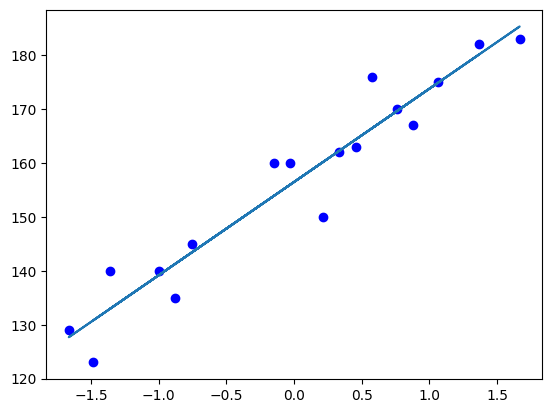

In [31]:
###Plot training data plot best fit line
plt.scatter(X_train, y_train, color='blue')
plt.plot(X_train,regression.predict(X_train))

### Prediction of test data
1. predicted height output=intercept+coef_(weights)
2. y_pred_test=156.470+17.29(X_test)

In [32]:
### Prediction for testdata
y_pred=regression.predict(X_test)

In [33]:
### Performance evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [34]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print("Mean Squared Error:",mse)
print("Mean Absolute Error:",mae)
print("Root Mean Squared Error:",rmse)

Mean Squared Error: 114.84069295228699
Mean Absolute Error: 9.66512588679501
Root Mean Squared Error: 10.716374991212605


In [35]:
from sklearn.metrics import r2_score
r2=r2_score(y_test,y_pred)
print("R-squared:",r2)

R-squared: 0.7360826717981276


In [41]:
### OLS Linerar Regressiom
!pip install statsmodels


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: C:\Python313\python.exe -m pip install --upgrade pip


In [42]:
import sys

In [43]:
print(sys.executable)

c:\Users\vikra\OneDrive\Pictures\Desktop\Code\venv\python.exe


In [44]:
import sys
!{sys.executable} -m pip install statsmodels

  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.5 MB 1.9 MB/s eta 0:00:05
   ---- ----------------------------------- 1.0/9.5 MB 1.9 MB/s eta 0:00:05
   ----- ---------------------------------- 1.3/9.5 MB 1.8 MB/s eta 0:00:05
   ------- -------------------------------- 1.8/9.5 MB 1.9 MB/s eta 0:00:05
   --------- ------------------------------ 2.4/9.5 MB 2.0 MB/s eta 0:00:04
   ------------ --------------------------- 2.9/9.5 MB 2.1 MB/s eta 0:00:04
   -------------- ------------------------- 3.4/9.5 MB 2.2 MB/s eta 0:00:03
   ----------------- ---------------------- 4.2/9.5 MB 2.3 MB/s eta 0:00:03
   ------------------ --------------------- 4.5/9.5 MB 2.3 MB/s eta 0:00:03
   -------------------- -------------------

In [45]:
import statsmodels.api as sm

print(sm.__version__)

0.14.6


In [46]:
model=sm.OLS(y_train,X_train).fit()

In [47]:
prediction=model.predict(X_test)
print(prediction)

[  5.79440897   5.79440897 -28.78711691  23.60913442  -7.82861638
  34.08838469]


In [48]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.012
Model:                            OLS   Adj. R-squared (uncentered):             -0.050
Method:                 Least Squares   F-statistic:                             0.1953
Date:                Thu, 18 Jun 2026   Prob (F-statistic):                       0.664
Time:                        09:39:37   Log-Likelihood:                         -110.03
No. Observations:                  17   AIC:                                      222.1
Df Residuals:                      16   BIC:                                      222.9
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [50]:
### Predicting the new data
regression.predict(scaler.transform([[72]]))

c:\Users\vikra\OneDrive\Pictures\Desktop\Code\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([155.97744705])